# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [2]:
liked_percentage = df['Liked'].mean() * 100

print(f"Percentage of reviews that liked the restaurant: {liked_percentage:.2f}%")

Percentage of reviews that liked the restaurant: 50.00%


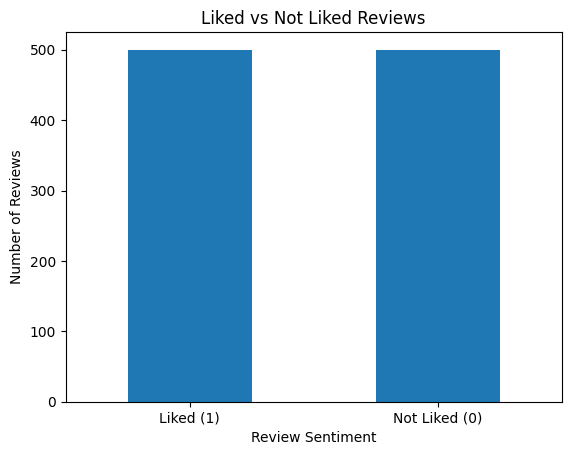

In [3]:
import matplotlib.pyplot as plt

counts = df['Liked'].value_counts()

plt.figure()
counts.plot(kind='bar')

plt.title("Liked vs Not Liked Reviews")
plt.xlabel("Review Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(ticks=[0,1], labels=["Liked (1)", "Not Liked (0)"], rotation=0)

plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

### In Your Response:
1. What risks might occur if you included the review "junk" in your model?


In [8]:
import re

In [9]:
df['Review'] = df['Review'].str.lower()

In [10]:
df['Review']= df['Review'].apply(lambda x: re.sub(r'http\S+', '', x))

In [11]:
df['Review'] = df['Review'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

### ✍️ Your Response: 🔧
1. Including junk like punctuation, URLs, or emojis can introduce noise and reduce model accuracy by treating irrelevant characters as meaningful patterns. This can change word frequencies and lead to misleading topic results.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%

### In Your Response:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)


In [12]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['Sentiment'] = df['Review'].apply(get_sentiment)

sentiment_percentages = df['Sentiment'].value_counts(normalize=True) * 100
print(sentiment_percentages)

Sentiment
positive    50.6
negative    25.5
neutral     23.9
Name: proportion, dtype: float64


### ✍️ Your Response: 🔧
1. The sentiment percentages usually align with the liked column. From a restaurant owner's perspective, negative reviews are most important because they highlight specific issues that need improvement.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

### In Your Response:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?


In [20]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [21]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w.isalnum()]
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens

df['Processed_Review'] = df['Review'].apply(preprocess)

df['Processed_Review'].head(10)

,Processed_Review
0,"[wow, loved, place]"
1,"[crust, good]"
2,"[tasty, texture, nasty]"
3,"[stopped, late, may, bank, holiday, rick, stev..."
4,"[selection, menu, great, price]"
5,"[getting, angry, want, damn, pho]"
6,"[honeslty, didnt, taste, fresh]"
7,"[potato, like, rubber, could, tell, made, ahea..."
8,"[fry, great]"
9,"[great, touch]"


### ✍️ Your Response: 🔧
1. A corpora is a collection of text datasets used in NLP to train and support tasks like tokenization, stopword filtering, and language processing.

2. The tokens would be, wow, loved, and place.

3. Lemmatization reduces words to their base form, which helps group similar words together and improves the quality and accuracy of topic analysis.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

### In Your Response:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

In [23]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 32.6 MB/s eta 0:00:00


In [24]:
from gensim.corpora import Dictionary

dictionary = Dictionary(df['Processed_Review'])

corpus = [dictionary.doc2bow(text) for text in df['Processed_Review']]

### ✍️ Your Response: 🔧
1. A corpus is a collection of documents represented in a structured format, and it is useful because it allows models like LDA to analyze word frequencies across all reviews.

2. A dictionary maps each unique word to an ID, while a corpus uses those IDs to represent each document as counts of words, making it ready for modeling.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

### In Your Response:
1. In what cases would you want to use more than 5 topics?  
2. How would you know if you have too many topics?

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [25]:
from gensim.models import LdaModel

num_topics = 5

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto'
)

for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.024*"good" + 0.019*"food" + 0.019*"place" + 0.014*"dont" + 0.011*"time" + 0.009*"best" + 0.008*"go" + 0.007*"really"
Topic 1: 0.016*"good" + 0.016*"place" + 0.012*"friendly" + 0.012*"time" + 0.010*"also" + 0.008*"ive" + 0.007*"go" + 0.007*"back"
Topic 2: 0.015*"place" + 0.012*"great" + 0.011*"minute" + 0.011*"food" + 0.010*"amazing" + 0.008*"like" + 0.007*"taste" + 0.007*"pretty"
Topic 3: 0.032*"food" + 0.022*"back" + 0.013*"like" + 0.012*"ever" + 0.011*"service" + 0.010*"wont" + 0.008*"go" + 0.008*"one"
Topic 4: 0.036*"service" + 0.023*"great" + 0.021*"place" + 0.015*"food" + 0.015*"good" + 0.010*"restaurant" + 0.008*"time" + 0.008*"delicious"


### ✍️ Your Response: 🔧
1. You would use more than 5 topics when the dataset is large, since more topics help capture finer-grained patterns in customer feedback.

2. You may have too many topics if they become repetitive, overlapping, or difficult to interpret, meaning the model is splitting similar ideas into multiple groups.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

### In Your Response:
1. Give each topic a 2-3 word name.  You should list the topic number and a name that you will create that summarize the words used.  For example, "Topic #1 - Slow Service"


In [26]:
topics = lda_model.print_topics(num_words=10)

for idx, topic in topics:
    print(f"Topic {idx}: {topic}")

Topic 0: 0.024*"good" + 0.019*"food" + 0.019*"place" + 0.014*"dont" + 0.011*"time" + 0.009*"best" + 0.008*"go" + 0.007*"really" + 0.007*"back" + 0.007*"would"
Topic 1: 0.016*"good" + 0.016*"place" + 0.012*"friendly" + 0.012*"time" + 0.010*"also" + 0.008*"ive" + 0.007*"go" + 0.007*"back" + 0.006*"waited" + 0.006*"like"
Topic 2: 0.015*"place" + 0.012*"great" + 0.011*"minute" + 0.011*"food" + 0.010*"amazing" + 0.008*"like" + 0.007*"taste" + 0.007*"pretty" + 0.006*"ordered" + 0.006*"flavor"
Topic 3: 0.032*"food" + 0.022*"back" + 0.013*"like" + 0.012*"ever" + 0.011*"service" + 0.010*"wont" + 0.008*"go" + 0.008*"one" + 0.008*"best" + 0.007*"going"
Topic 4: 0.036*"service" + 0.023*"great" + 0.021*"place" + 0.015*"food" + 0.015*"good" + 0.010*"restaurant" + 0.008*"time" + 0.008*"delicious" + 0.007*"definitely" + 0.006*"well"


In [27]:
import pandas as pd

def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

df['Topic'] = [get_dominant_topic(doc) for doc in corpus]

df[['Review', 'Topic']].head()

,Review,Topic
0,wow loved this place,1
1,crust is not good,1
2,not tasty and the texture was just nasty,1
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,0


In [28]:
topic_counts = df['Topic'].value_counts().sort_index()
print(topic_counts)

Topic
0    199
1    160
2    172
3    212
4    257
Name: count, dtype: int64


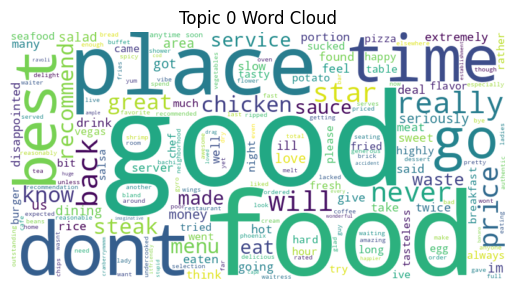

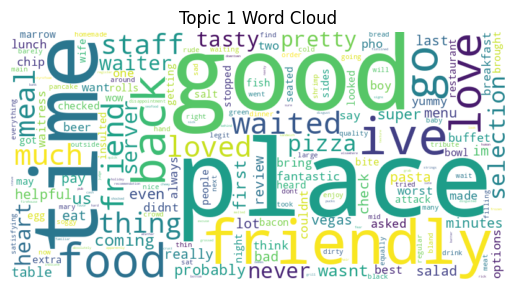

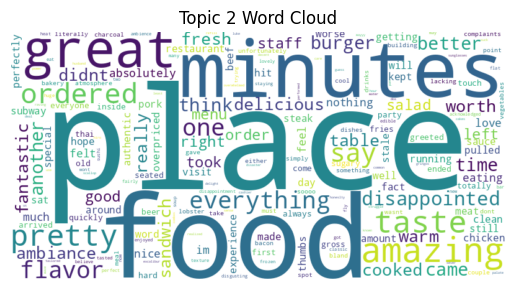

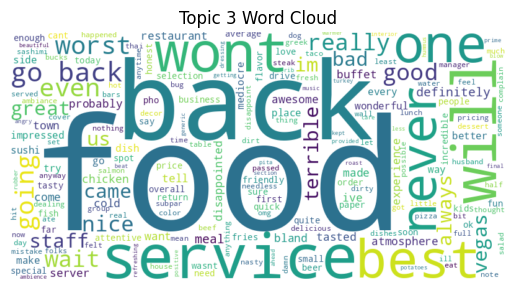

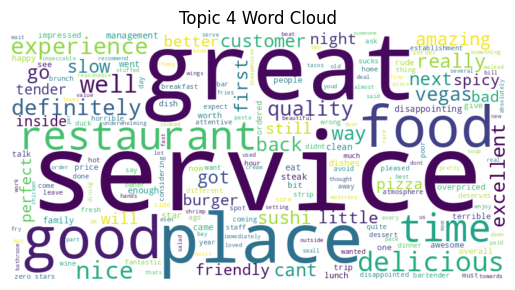

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for t in range(num_topics):
    text = " ".join(df[df['Topic'] == t]['Review'])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure()
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {t} Word Cloud")
    plt.show()

In [30]:
sentiment_by_topic = pd.crosstab(df['Topic'], df['Sentiment'], normalize='index') * 100
print(sentiment_by_topic)

Sentiment   negative    neutral   positive
Topic                                     
0          23.115578  27.638191  49.246231
1          25.625000  23.750000  50.625000
2          27.325581  22.674419  50.000000
3          28.773585  30.188679  41.037736
4          23.346304  16.731518  59.922179


### ✍️ Your Response: 🔧
List your topics and names here:

Topic 0 - Food Quality
Topic 1 - Service Experience
Topic 2 - Restaurant Atmosphere
Topic 3 - Price & Value
Topic 4 - Negative Experience


## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response: 🔧
1. The model helped answer what specific issues customers are talking about in their reviews and how those themes relate to positive or negative sentiment.

2. The restaurant should focus on improving the most negatively associated topics while maintaining strengths in high-sentiment areas like food quality and atmosphere. Addressing recurring complaints in negative-topic reviews would likely increase overall customer ratings.

3. LLMs are faster to use and can generate more human-like summaries and insights without requiring complex coding. However, traditional Python models like LDA are more transparent and better for structured quantitative analysis, while LLM outputs can sometimes be less consistent.

4. Prompt: You are a data analyst working for a restaurant. I will provide 100 customer reviews. Your task is to identify the main topics discussed in the reviews, group them into 4-6 categories, and summarize each topic with a short 2-3 word label. Then analyze sentiment within each topic and explain what business actions the restaurant should take to improve customer satisfaction. Present results in a structured format with clear headings and concise business insights.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [31]:
!jupyter nbconvert --to html "assignment_13_text_analytics_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook assignment_13_text_analytics_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1496595 bytes to assignment_13_text_analytics_MonbergTobin.html
